Import Libraries

In [76]:
import pandas as pd
import numpy as py
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Import Dataset

In [77]:
df = pd.read_csv("simulated-data-raw1.csv")

Understanding Data

In [78]:
df.head()

,Unnamed: 0,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,0,2024-04-01 00:00:31,596,1337,57.16,31,0,0,0
1,1,1,2024-04-01 00:07:56,2,523,146.00,476,0,0,0
2,2,2,2024-04-01 00:10:34,927,824,50.99,634,0,0,0
3,3,3,2024-04-01 00:10:45,568,4805,44.71,645,0,0,0
4,4,4,2024-04-01 00:13:44,541,3260,59.07,824,0,0,0


In [79]:
df.sample(10)

,Unnamed: 0,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
309978,309978,309978,2024-06-04 15:28:38,1636,1676,120.41,5585318,64,0,0
288193,288193,288193,2024-05-31 06:54:18,530,1929,6.36,5208858,60,0,0
91582,91582,91582,2024-04-20 07:13:40,879,1970,66.99,1667620,19,0,0
347690,347690,347690,2024-06-12 13:50:10,684,957,3.68,6270610,72,0,0
182476,182476,182476,2024-05-09 05:55:28,1881,4786,46.23,3304528,38,0,0
129009,129009,129009,2024-04-27 22:30:12,1050,351,27.77,2327412,26,0,0
232940,232940,232940,2024-05-19 13:50:56,2115,248,71.11,4197056,48,0,0
156117,156117,156117,2024-05-03 13:42:35,800,208,73.38,2814155,32,0,0
83390,83390,83390,2024-04-18 11:33:21,1173,1184,27.86,1510401,17,0,0
326108,326108,326108,2024-06-08 05:47:35,1525,4069,100.24,5896055,68,0,0


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383087 entries, 0 to 383086
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         383087 non-null  int64  
 1   TRANSACTION_ID     383087 non-null  int64  
 2   TX_DATETIME        383087 non-null  object 
 3   CUSTOMER_ID        383087 non-null  int64  
 4   TERMINAL_ID        383087 non-null  int64  
 5   TX_AMOUNT          383087 non-null  float64
 6   TX_TIME_SECONDS    383087 non-null  int64  
 7   TX_TIME_DAYS       383087 non-null  int64  
 8   TX_FRAUD           383087 non-null  int64  
 9   TX_FRAUD_SCENARIO  383087 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 29.2+ MB


In [81]:
df.describe()

,Unnamed: 0,TRANSACTION_ID,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
count,383087.000000,383087.000000,383087.000000,383087.000000,383087.000000,3.830870e+05,383087.000000,383087.000000,383087.000000
mean,191543.000000,191543.000000,1250.086142,2498.017630,54.166366,3.457548e+06,39.518498,0.015054,0.034535
std,110587.835624,110587.835624,720.353354,1447.598131,45.600638,1.994220e+06,23.080303,0.121768,0.286666
min,0.000000,0.000000,0.000000,0.000000,0.000000,3.100000e+01,0.000000,0.000000,0.000000
25%,95771.500000,95771.500000,627.000000,1240.000000,21.220000,1.742742e+06,20.000000,0.000000,0.000000
50%,191543.000000,191543.000000,1250.000000,2497.000000,44.850000,3.456763e+06,40.000000,0.000000,0.000000
75%,287314.500000,287314.500000,1871.000000,3755.000000,77.290000,5.177722e+06,59.000000,0.000000,0.000000
max,383086.000000,383086.000000,2499.000000,4999.000000,4016.500000,6.911981e+06,79.000000,1.000000,3.000000


In [82]:
df["TX_FRAUD"].value_counts()

TX_FRAUD
0    377320
1      5767
Name: count, dtype: int64

In [83]:
df["TX_FRAUD_SCENARIO"].value_counts()

TX_FRAUD_SCENARIO
0    377320
2      3681
3      1891
1       195
Name: count, dtype: int64

In [84]:
df.isnull().sum()

Unnamed: 0           0
TRANSACTION_ID       0
TX_DATETIME          0
CUSTOMER_ID          0
TERMINAL_ID          0
TX_AMOUNT            0
TX_TIME_SECONDS      0
TX_TIME_DAYS         0
TX_FRAUD             0
TX_FRAUD_SCENARIO    0
dtype: int64

Data Cleaning

In [85]:
df_clean = df
df_clean.head()

,Unnamed: 0,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,0,2024-04-01 00:00:31,596,1337,57.16,31,0,0,0
1,1,1,2024-04-01 00:07:56,2,523,146.00,476,0,0,0
2,2,2,2024-04-01 00:10:34,927,824,50.99,634,0,0,0
3,3,3,2024-04-01 00:10:45,568,4805,44.71,645,0,0,0
4,4,4,2024-04-01 00:13:44,541,3260,59.07,824,0,0,0


In [86]:
import sqlite3
import pandas as pd

# SQL
df_test = df.copy()
conn = sqlite3.connect(':memory:')

# Save DataFrame to the database as a table called 'transactions'
df_test.to_sql('transactions', conn, index=False, if_exists='replace')

# SQL query to add transactions in last hour, and amount in last hour per customer
query = """
SELECT
    t1.*,
    COUNT(t2.TX_AMOUNT) AS TXs_LAST_1H,
    COALESCE(SUM(t2.TX_AMOUNT), 0) AS AMOUNT_LAST_1H
FROM transactions t1
LEFT JOIN transactions t2
    ON t1.CUSTOMER_ID = t2.CUSTOMER_ID
    AND t2.TX_TIME_SECONDS BETWEEN t1.TX_TIME_SECONDS - 3600 AND t1.TX_TIME_SECONDS
GROUP BY t1.ROWID
"""

# Run the query
df_result = pd.read_sql_query(query, conn)
conn.close()


In [87]:
# calc standard deviation ,to know if a customer normally has spread out diferrent amounts in transactions or not
# if else bec std needs atleast 2 inputs
def fun(group):
    if len(group)>1:
        return round(group["TX_AMOUNT"].std(), 2)
    return 0

# use reset_index to fix mult-index issue with groupby
df_clean["CUSTOMER_STD"] = df_clean.groupby("CUSTOMER_ID").apply(fun).reset_index(level=0, drop=True).round(2)

df_clean.head()

,Unnamed: 0,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,CUSTOMER_STD
0,0,0,2024-04-01 00:00:31,596,1337,57.16,31,0,0,0,27.50
1,1,1,2024-04-01 00:07:56,2,523,146.00,476,0,0,0,47.90
2,2,2,2024-04-01 00:10:34,927,824,50.99,634,0,0,0,58.69
3,3,3,2024-04-01 00:10:45,568,4805,44.71,645,0,0,0,4.85
4,4,4,2024-04-01 00:13:44,541,3260,59.07,824,0,0,0,76.46


In [88]:
# calc z-score to cheack if customer transaction is sus according to its std (std column may not be very usefull after this)
def fun(group):
    z_score = (group["TX_AMOUNT"] - group["TX_AMOUNT"].mean()) / group["CUSTOMER_STD"]
    return z_score

df_clean["Z_SCORE"] = df_clean.groupby("CUSTOMER_ID").apply(fun).reset_index(level=0, drop=True).round(2)
df_clean.head()

,Unnamed: 0,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,CUSTOMER_STD,Z_SCORE
0,0,0,2024-04-01 00:00:31,596,1337,57.16,31,0,0,0,27.50,0.51
1,1,1,2024-04-01 00:07:56,2,523,146.00,476,0,0,0,47.90,1.28
2,2,2,2024-04-01 00:10:34,927,824,50.99,634,0,0,0,58.69,-0.06
3,3,3,2024-04-01 00:10:45,568,4805,44.71,645,0,0,0,4.85,2.62
4,4,4,2024-04-01 00:13:44,541,3260,59.07,824,0,0,0,76.46,0.19


In [89]:
# add amount to avg ratio
def fun(group):
    return group["TX_AMOUNT"] / group["TX_AMOUNT"].mean()

df_clean["AMOUNT_TO_AVG_RATIO"] = df_clean.groupby("CUSTOMER_ID").apply(fun).reset_index(level=0, drop=True).round(2)
df_clean.head()

,Unnamed: 0,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,CUSTOMER_STD,Z_SCORE,AMOUNT_TO_AVG_RATIO
0,0,0,2024-04-01 00:00:31,596,1337,57.16,31,0,0,0,27.50,0.51,1.33
1,1,1,2024-04-01 00:07:56,2,523,146.00,476,0,0,0,47.90,1.28,1.72
2,2,2,2024-04-01 00:10:34,927,824,50.99,634,0,0,0,58.69,-0.06,0.94
3,3,3,2024-04-01 00:10:45,568,4805,44.71,645,0,0,0,4.85,2.62,1.40
4,4,4,2024-04-01 00:13:44,541,3260,59.07,824,0,0,0,76.46,0.19,1.33


In [90]:
df_clean.sample(10)

,Unnamed: 0,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,CUSTOMER_STD,Z_SCORE,AMOUNT_TO_AVG_RATIO
346271,346271,346271,2024-06-12 09:40:37,493,1034,5.03,6255637,72,0,0,NaN,NaN,0.93
22538,22538,22538,2024-04-05 15:12:37,25,1693,93.76,400357,4,0,0,NaN,NaN,1.21
245404,245404,245404,2024-05-22 07:30:14,2086,3390,51.10,4433414,51,0,0,NaN,NaN,1.09
98033,98033,98033,2024-04-21 12:36:06,403,412,7.30,1773366,20,0,0,NaN,NaN,0.12
341708,341708,341708,2024-06-11 10:19:28,976,690,61.31,6171568,71,0,0,NaN,NaN,1.03
121613,121613,121613,2024-04-26 11:02:42,1052,2804,88.51,2199762,25,0,0,NaN,NaN,1.06
23623,23623,23623,2024-04-05 20:39:59,2355,2100,19.80,419999,4,0,0,NaN,NaN,1.08
290169,290169,290169,2024-05-31 13:12:29,2448,3001,54.15,5231549,60,0,0,NaN,NaN,1.14
286281,286281,286281,2024-05-30 15:51:55,1250,319,0.50,5154715,59,0,0,NaN,NaN,0.04
139577,139577,139577,2024-04-30 06:55:50,2393,2137,9.45,2530550,29,0,0,NaN,NaN,1.25


In [91]:
# Convert to datetime
df_clean["TX_DATETIME"] = pd.to_datetime(df_clean["TX_DATETIME"])

# Now extract hour of transaction 
# And day of week of transaction starting from (sunday = 1,... saturday = 7)
df_clean["TX_HOUR"] = df_clean["TX_DATETIME"].dt.hour
df_clean["TX_DAY"] = df_clean["TX_DATETIME"].dt.dayofweek + 1

In [102]:
# flag for if terminal used is not the same as previous one
df_clean['NEW_TERMINAL_FLAG'] = df_clean.groupby('CUSTOMER_ID')['TERMINAL_ID'].apply(lambda x: x != x.shift()).astype(int)

TypeError: incompatible index of inserted column with frame index

In [115]:
# making temp column unique terminal count in same hour same day
df_clean['unique_terminal_count'] = df_clean.groupby(['CUSTOMER_ID', 'TX_HOUR', 'TX_DAY'])['TERMINAL_ID'].transform('nunique')

df_clean['MULTI_TERMINAL_FLAG'] = (df_clean['unique_terminal_count'] >= 3).reset_index(drop=True).astype(int)
df_clean.drop(columns='unique_terminal_count', axis=1, inplace=True)

In [ ]:
# Drop columns
df_clean.drop(columns=["Unnamed: 0", "TX_DATETIME"] ,axis=1 , inplace=True)
df_clean.sample(5)

In [117]:
# Adding is_night column (from 11 pm to 6 am) and is_weekend column (5,6,7 => weekend)
df_clean["IS_NIGHT"] = ((df_clean['TX_HOUR'] == 23) | ((df_clean['TX_HOUR'] >= 0) & (df_clean['TX_HOUR'] <= 6))).astype(int)
df_clean["IS_WEEKEND"] = (df_clean['TX_DAY'] > 4).astype(int)

df_clean.head()

,TRANSACTION_ID,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,CUSTOMER_STD,Z_SCORE,AMOUNT_TO_AVG_RATIO,TX_HOUR,TX_DAY,IS_NIGHT,IS_WEEKEND,MULTI_TERMINAL_FLAG
0,0,596,1337,57.16,31,0,0,0,27.50,0.51,1.33,0,1,1,0,0
1,1,2,523,146.00,476,0,0,0,47.90,1.28,1.72,0,1,1,0,0
2,2,927,824,50.99,634,0,0,0,58.69,-0.06,0.94,0,1,1,0,0
3,3,568,4805,44.71,645,0,0,0,4.85,2.62,1.40,0,1,1,0,0
4,4,541,3260,59.07,824,0,0,0,76.46,0.19,1.33,0,1,1,0,0


In [118]:
df_clean.sample(10)

,TRANSACTION_ID,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,CUSTOMER_STD,Z_SCORE,AMOUNT_TO_AVG_RATIO,TX_HOUR,TX_DAY,IS_NIGHT,IS_WEEKEND,MULTI_TERMINAL_FLAG
118771,118771,1312,3693,2.78,2135469,24,0,0,NaN,NaN,0.42,17,4,0,0,0
78765,78765,1619,1758,120.23,1425791,16,0,0,NaN,NaN,1.35,12,3,0,0,1
238237,238237,2241,4150,22.13,4288514,49,0,0,NaN,NaN,0.58,15,1,0,0,0
129986,129986,847,2944,80.46,2359077,27,0,0,NaN,NaN,0.80,7,7,0,1,1
139595,139595,1664,4187,66.40,2530814,29,0,0,NaN,NaN,1.13,7,2,0,0,1
33373,33373,316,3462,86.58,615476,7,0,0,NaN,NaN,1.00,2,1,1,0,0
265064,265064,2462,3769,115.64,4787518,55,0,0,NaN,NaN,1.35,9,7,0,1,0
184375,184375,678,3209,11.29,3327661,38,0,0,NaN,NaN,0.53,12,4,0,0,1
102031,102031,1502,3738,38.07,1852013,21,0,0,NaN,NaN,0.82,10,1,0,0,1
164838,164838,1619,1016,137.75,2978081,34,0,0,NaN,NaN,1.55,11,7,0,1,1


Plotting the data to get clear insights

Text(0.5, 1.0, 'The Fraud Transactions are 1.51% of the dataset')

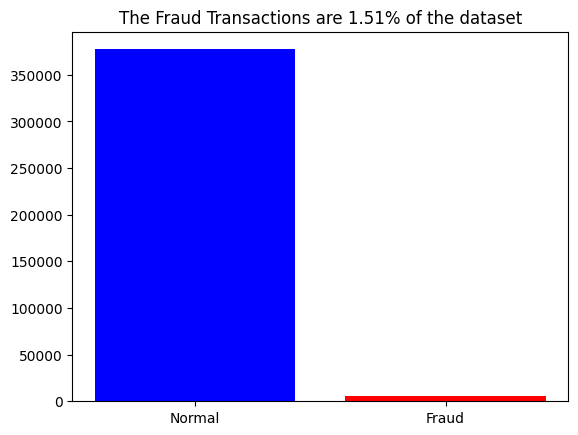

In [94]:
Normal_len = len(df[df["TX_FRAUD"]==0])
Fraud_len = len(df[df["TX_FRAUD"]==1])

plt.bar([0 ,1], [Normal_len, Fraud_len], color=['b' ,'r'])
plt.xticks([0, 1], ["Normal", "Fraud"])

t = round((Fraud_len/len(df) * 100),2)
plt.title(f"The Fraud Transactions are {t}% of the dataset")

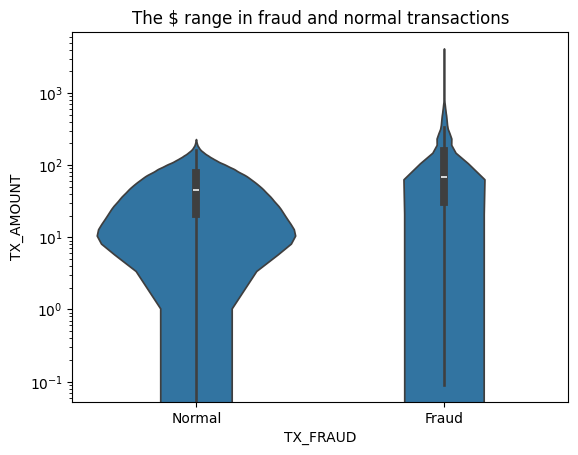

In [95]:
sns.violinplot(x='TX_FRAUD', y='TX_AMOUNT',  data=df_clean)
plt.xticks([0, 1], ["Normal", "Fraud"])
plt.yscale("log")
plt.title("The $ range in fraud and normal transactions")
plt.show()

In [96]:
sns.violinplot(x='TX_FRAUD', y='TX_TIME',  data=df_clean)
plt.xticks([0, 1], ["Normal", "Fraud"])
plt.title("The time of fraud and normal transactions")
plt.show()

ValueError: Could not interpret value `TX_TIME` for `y`. An entry with this name does not appear in `data`.

In [ ]:
df.to_csv('DataCleaned')